In this simple notebook we use a fully connected neural network to solve a previously seen problem, the particle ID classification (see notebooks of Chapter 4 for more detail).

It accompanies Chapter 8 of the book (1 of 2).

Copyright: Viviana Acquaviva (2023).

Modifications by Julieta Gruszko (2025).

License: [BSD-3-clause](https://opensource.org/license/bsd-3-clause/)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.utils import shuffle

In [2]:
import matplotlib
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 150)

font = {'size'   : 16}
matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=14) 
matplotlib.rc('ytick', labelsize=14) 
matplotlib.rcParams['figure.dpi'] = 300

Pytorch is the most commonly used library for development of Deep Learning models. It is an open-source platform for python that also enables the use of multiple GPU platforms, like CUDA.

Keras is a high-level API (Application Programming Interface) that is built on top of a deep learning library. Originally it was developed for tensorflow, but these days it supports multiple back-ends including pytorch. We can think of it as the equivalent of the sklearn library for neural networks. It is less general, and less customizable, but it is very user-friendly. 

Another option for similar API tools, built into pytorch directly, would be to use pytorch.nn . This is the more common option, but we'd lose access to some of the nice hyperparameter tuning options that interface with keras (and have to replace them with equivalent pytorch-compatible libraries, which do exist if you want to go that route). 

In [3]:
import torch as torch

In [4]:
torch.__version__

'2.6.0'

This is how you set keras to use the pytorch back-end:

In [5]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [6]:
import keras

from keras.models import Sequential #the model is built adding layers one after the other

from keras.layers import Dense #fully connected layers: every output talks to every input

from keras.layers import Dropout #for regularization

from keras import Input

We begin with the 4top vs ttbar problem, and we use the configuration where we added the features "number of leptons", "number of jets" etc., but not the particle type for every track.

For reference, the linear SVM with those features achieved 94.2% +/- 0.6% accuracy. Note that those numbers had not been run through <b> nested </b> cross validation so they might be slightly optimistic. 

Luckily we saved the data with our added feature engineering back then, we can just load it now:

In [7]:
X = pd.read_csv('../Data/Features_lim_2.csv')

In [8]:
y = np.genfromtxt('../Data/Labels_lim_2.txt')

In [9]:
X.values.shape

(5000, 24)

Just to remind ourselves what's in there:

In [10]:
display(X)

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
0,0,62803.5,-1.810010,137571.0,128444.0,-0.345744,-0.307112,174209.0,127932.0,0.826569,2.332000,86788.9,84554.9,-0.180795,2.187970,140289.0,76955.8,-1.199330,-1.302800,5,1,3,0,1
1,1,57594.2,-0.509253,161529.0,80458.3,-1.318010,1.402050,291490.0,68462.9,-2.126740,-2.582310,44270.1,35139.6,-0.706120,-0.371392,72883.9,26902.2,-1.653860,-3.129630,4,0,2,0,2
2,2,82313.3,1.686840,167130.0,113078.0,0.937258,-2.068680,102423.0,54922.3,1.226850,0.646589,60768.9,36244.3,1.102890,-1.434480,77714.0,27801.5,1.684610,1.389690,5,1,4,0,0
3,3,30610.8,2.617120,112267.0,61383.9,-1.211050,-1.457800,40647.8,39472.0,-0.024646,-2.222800,201589.0,32978.6,-2.496040,1.137810,90096.7,26964.5,1.871320,0.817631,5,1,4,0,0
4,4,45153.1,-2.241350,178174.0,100164.0,1.166880,-0.018721,92351.3,69762.1,0.774114,2.568740,61625.2,50086.7,0.652572,-3.012800,104193.0,31151.0,1.876410,0.865381,5,0,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,269074.0,-1.274730,495577.0,362590.0,-0.791914,1.671250,328278.0,224827.0,0.922952,-1.284970,2628790.0,178652.0,-3.380790,2.922260,303713.0,156021.0,-1.284190,0.436475,10,2,8,0,0
4996,4996,12385.8,0.986871,258932.0,133559.0,-1.276540,2.970100,87822.2,73895.0,0.604704,-0.646550,104199.0,67035.4,-1.003020,-0.909438,60343.9,38512.4,-1.013560,0.770876,5,1,4,0,0
4997,4997,32762.8,3.057630,122222.0,79947.8,0.983920,-0.399231,260623.0,49940.6,2.334630,0.555659,56696.1,49853.1,0.422515,-3.014610,36338.9,25777.1,0.850436,0.672009,5,1,4,0,0
4998,4998,104474.0,-1.875250,791028.0,457589.0,1.141530,2.934810,304661.0,224326.0,0.793147,0.407167,569714.0,151015.0,2.002460,-0.778558,83117.9,79371.7,-0.234668,-0.225965,9,2,5,0,2


There is no "built-in" cross validation process here, so we would need to build it ourselves. For now, we can build three sets: train, validation (for parameter optimization), and test (for final evaluation). We should ideally build this as a cross-validation structure.

In [11]:
#Always shuffle first

X,y = shuffle(X,y, random_state = 10)

In [12]:
X_train = X.values[:3000,:]
y_train = y[:3000]

In [13]:
X_val = X.values[3000:4000,:]
y_val = y[3000:4000]

In [14]:
X_test = X.values[4000:,:]
y_test = y[4000:]

In [15]:
X_train.shape, X_val.shape, X_test.shape

((3000, 24), (1000, 24), (1000, 24))

### Building the network

Let's think about the model architecture.

For a fully-connected neural net, we always start with one neuron per feature at the input layer. At the output, we want to perform a classification task. One nice way to build a classifier is to output the probability of having membership in the positive class as the target value. 

### Question:
- How many neurons should our input layer have, in this case?
- How many neurons should our output layer have, in this case?
- What would be a reasonable differentiable activation function for our output layer? Hint: think about what range of values our network should return to work as a classifier.

>There should be 24 neurons in the input layer. 

>There should be one neuron for the output (just the probability). 

>The sigmoid would be a reasonable differentiable activation function for the output layer. 

In addition to the input and output layers, we will add two hidden layers. Here we are making both sizes = 20 (we should optimize this hyperparameter!). We can also reserve the possibility of adding a dropout layer after each one, in case we decide we could benefit from regularization. The dropout fraction should also be optimized through CV.

Other decisions that we have to make are: 
- which nonlinearities we use
- which optimizer we use
- the loss function




The commands below can be used to explore possible choices.

In [16]:
dir(keras.activations)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'celu',
 'deserialize',
 'elu',
 'exponential',
 'gelu',
 'get',
 'glu',
 'hard_shrink',
 'hard_sigmoid',
 'hard_silu',
 'hard_swish',
 'hard_tanh',
 'leaky_relu',
 'linear',
 'log_sigmoid',
 'log_softmax',
 'mish',
 'relu',
 'relu6',
 'selu',
 'serialize',
 'sigmoid',
 'silu',
 'soft_shrink',
 'softmax',
 'softplus',
 'softsign',
 'sparse_plus',
 'sparse_sigmoid',
 'sparsemax',
 'squareplus',
 'swish',
 'tanh',
 'tanh_shrink',
 'threshold']

We'll use ReLU for hidden layers, sigmoid for the output layer.

In [17]:
dir(keras.optimizers)

['Adadelta',
 'Adafactor',
 'Adagrad',
 'Adam',
 'AdamW',
 'Adamax',
 'Ftrl',
 'Lamb',
 'Lion',
 'LossScaleOptimizer',
 'Muon',
 'Nadam',
 'Optimizer',
 'RMSprop',
 'SGD',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'deserialize',
 'get',
 'legacy',
 'schedules',
 'serialize']

AdamW is a good "default option" to start with, we'll use that.

In [18]:
dir(keras.losses)

['BinaryCrossentropy',
 'BinaryFocalCrossentropy',
 'CTC',
 'CategoricalCrossentropy',
 'CategoricalFocalCrossentropy',
 'CategoricalGeneralizedCrossEntropy',
 'CategoricalHinge',
 'Circle',
 'CosineSimilarity',
 'Dice',
 'Hinge',
 'Huber',
 'KLDivergence',
 'LogCosh',
 'Loss',
 'MeanAbsoluteError',
 'MeanAbsolutePercentageError',
 'MeanSquaredError',
 'MeanSquaredLogarithmicError',
 'Poisson',
 'SparseCategoricalCrossentropy',
 'SquaredHinge',
 'Tversky',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'binary_crossentropy',
 'binary_focal_crossentropy',
 'categorical_crossentropy',
 'categorical_focal_crossentropy',
 'categorical_generalized_cross_entropy',
 'categorical_hinge',
 'circle',
 'cosine_similarity',
 'ctc',
 'deserialize',
 'dice',
 'get',
 'hinge',
 'huber',
 'kl_divergence',
 'log_cosh',
 'mean_absolute_error',
 'mean_absolute_percentage_error',
 'mean_squared_error',
 'mean_squared_logarith

A standard choice for a case like ours, where the labels are 0/1 but we can predict a probability, is the binary cross-entropy or log loss:

L = - $\frac{1}{N} \sum_{i=1}^N y_i \cdot log(p(y_i)) + (1-y_i) \cdot log (1 - p(y_i))$

p is the probability that an object belongs to the positive class. It penalizes positive examples that are associated with predicted low probability, and negative examples that are associated with predicted high probability.

We also have to make initial choices for our training hyperparameters:
- which starting learning rate we adopt: we'll start with 0.001, but again this should be decided through CV
- the number of epochs: e.g. 100; we can plot quantities of interest to check that we have enough
- the batch size for the gradient descent step: here 200, but can explore! Smaller batch sizes will be faster but less stable in terms of convergence. 

### Question:
What is the difference between the number of epochs and the batch size? Describe how each is used.

>Epochs is the number of times the model is trained before gradient descent is used. 

>The batch size is the number of data points (features) that gradient descent uses to converge. 

### This is how we build a fully connected neural network in keras.

The pytorch back-end throws a warning because of a bug here, but you can safely ignore it.

In [19]:
model = Sequential()

# Tell subsequent layers what shape to expect. Keras can also infer this from the data, but it's slower
model.add(keras.Input(shape=(24,)))

# Add an input layer and specify its size (number of original features)

model.add(Dense(20, activation='relu', input_shape=(24,)))

# Add one hidden layer and specify its size

model.add(Dense(20, activation='relu'))

# Add an output layer 

model.add(Dense(1, activation='sigmoid'))

optimizer = keras.optimizers.AdamW(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) 

/opt/anaconda3/envs/phy448_deeplearning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


The "metric" keyword here serves to specify other possible metrics we would like to monitor. The loss itself is not interpretable, so we'll keep an eye on the accuracy.

### Question:
- How are the neuron weights being initialized for each layer?
- How are the biases being initialized for each layer?

Hint: You'll probably need to look at the Keras API documenation, found here: https://keras.io/api/

>"Draws samples from a uniform distribution within [-limit, limit], where limit = sqrt(6 / (fan_in + fan_out)) (fan_in is the number of input units in the weight tensor and fan_out is the number of output units)." -Keras documentation

>The biases are being initialized to zeros for each layer. 

### Ready to fit?

In [20]:
mynet = model.fit(X_train, y_train, validation_data= (X_val, y_val), epochs = 100,  batch_size=200)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4520 - loss: 8.7486 - val_accuracy: 0.6000 - val_loss: 6.3966
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6513 - loss: 5.5745 - val_accuracy: 0.6990 - val_loss: 4.8234
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7230 - loss: 4.4429 - val_accuracy: 0.7160 - val_loss: 4.5526
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7180 - loss: 4.5223 - val_accuracy: 0.7080 - val_loss: 4.6801
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7223 - loss: 4.4506 - val_accuracy: 0.7300 - val_loss: 4.3306
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7427 - loss: 4.1295 - val_accuracy: 0.7410 - val_loss: 4.1553
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7480 - loss: 4.0445 - val_accuracy: 0.7450 - val_loss: 4.0917
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7487 - loss: 4.0340 - val_accuracy: 0.

The train and validation accuracy don't look so good.

It's helpful to plot how training and validation loss vary throughout the epochs.

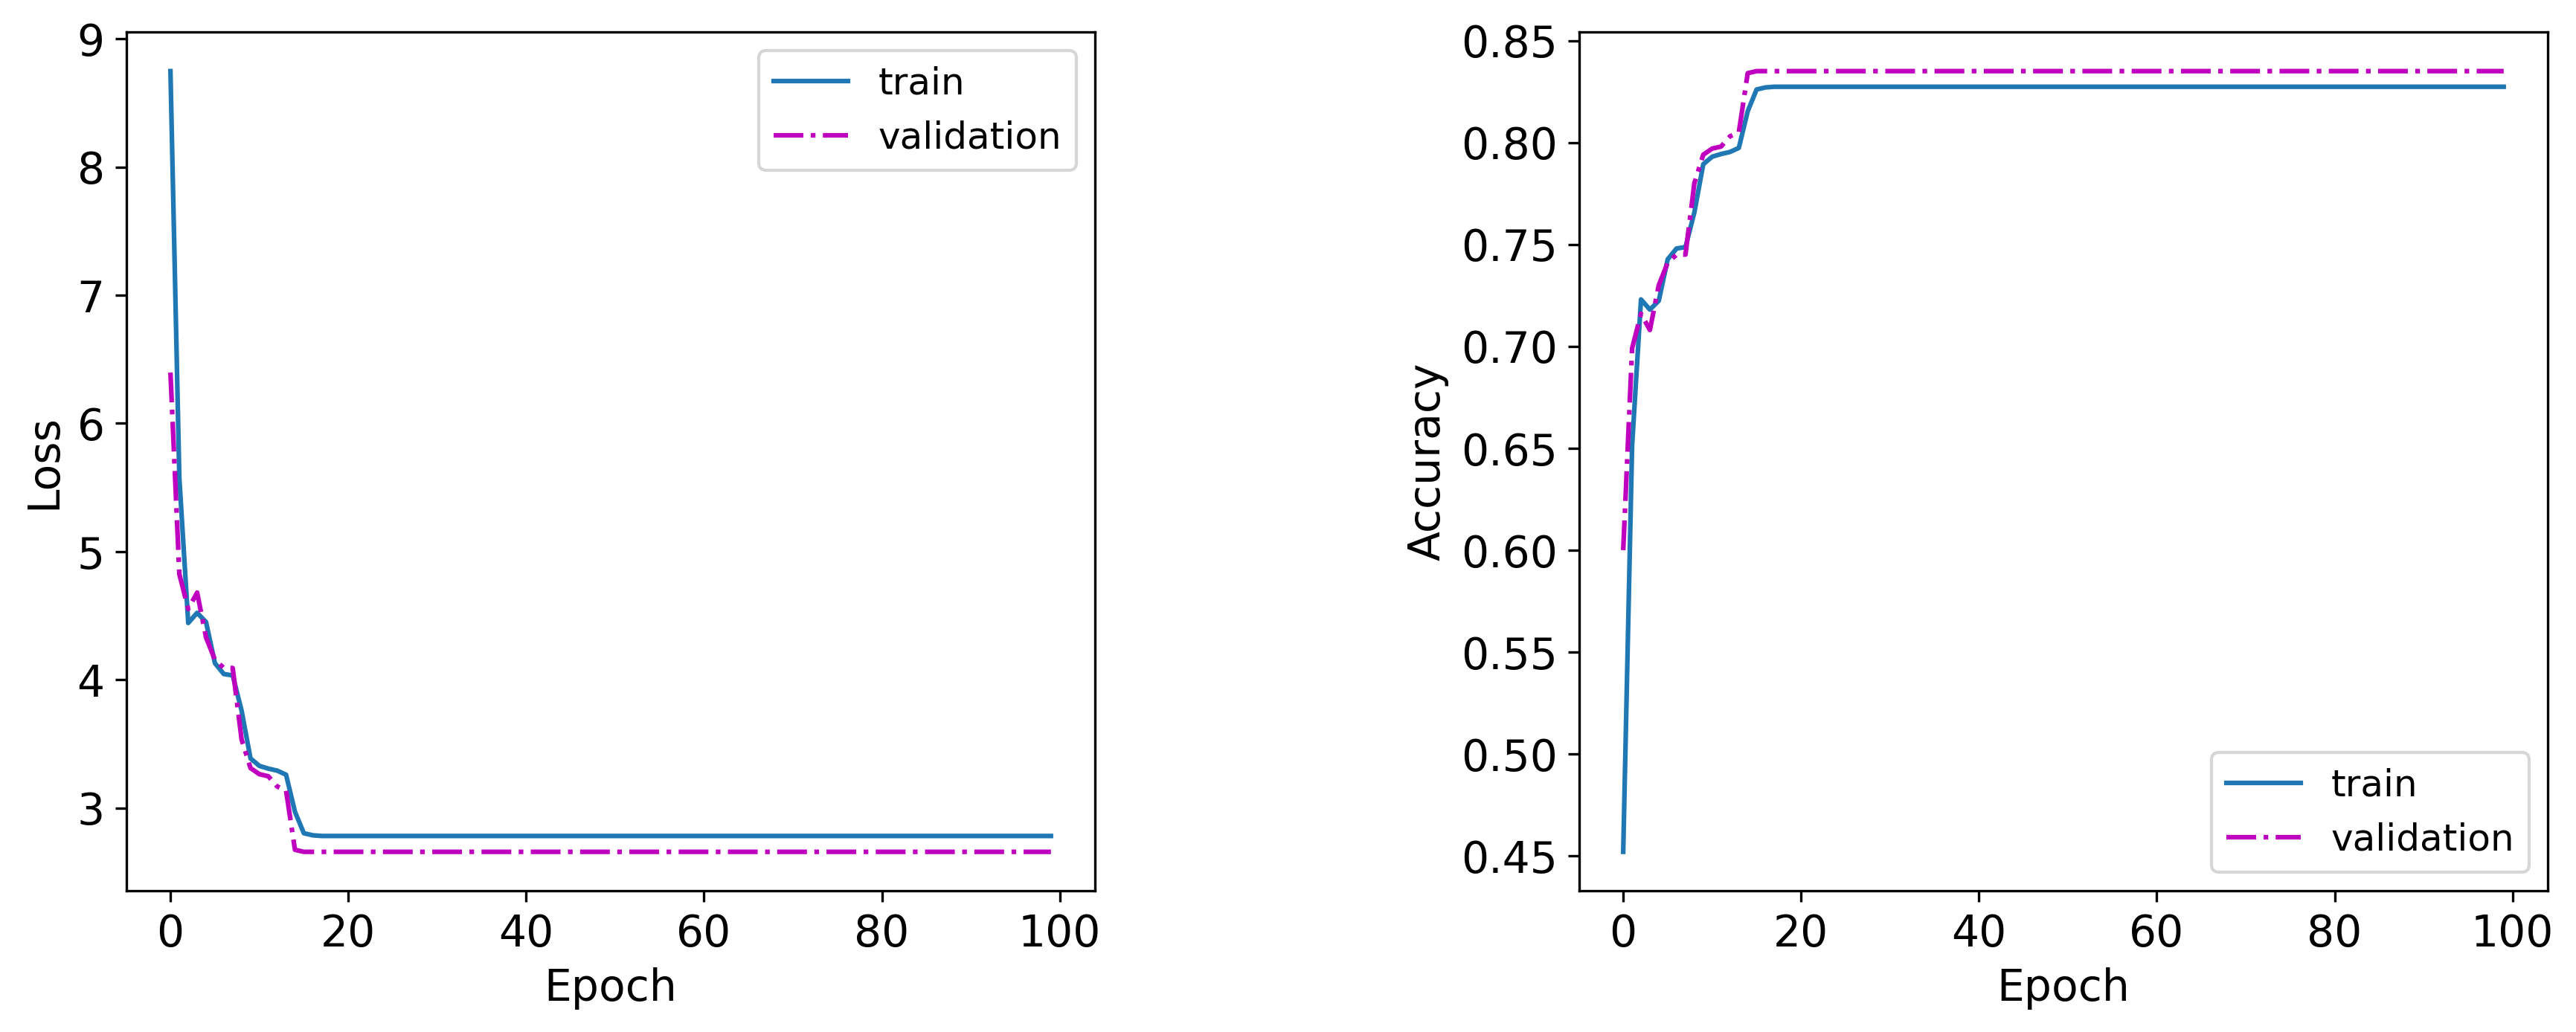

In [21]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train')
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.show()

#plt.savefig('FirstNN.png', dpi= 300)

There's no sign of any convergence/improvement here! 
### Question:
Any ideas to fix it? What step(s) did we skip?

>We forgot to scale the data. 

When in doubt, take a look at the data again!

In [22]:
X.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,P8,P9,P10,P11,P12,P13,P14,P15,P16,Total_products,Total_b,Total_j,Total_g,Total_leptons
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5.000000e+03,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.526283e+05,1.079653e+05,-0.029918,0.007323,2.096800e+05,74114.709700,-0.024853,0.011727,1.703778e+05,54046.489280,0.010116,0.042704,6.245400,1.418200,4.49240,0.030400,0.304400
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638514e+05,8.138121e+04,1.438673,1.828283,2.506651e+05,46675.655162,1.569410,1.793678,2.352279e+05,33795.723384,1.587146,1.760070,2.157709,0.955767,2.03479,0.171702,0.519418
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,0.000000e+00,0.000000e+00,-4.668790,-3.140530,0.000000e+00,0.000000,-4.520250,-3.141480,0.000000e+00,0.000000,-4.616550,-3.136130,1.000000,0.000000,0.00000,0.000000,0.000000
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007050e+05,6.320943e+04,-1.059270,-1.599617,7.488228e+04,46165.375000,-1.108390,-1.532478,5.480870e+04,33959.400000,-1.050477,-1.424080,5.000000,1.000000,3.00000,0.000000,0.000000
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.658985e+05,8.581595e+04,-0.056810,0.012737,1.277135e+05,62167.100000,-0.023321,0.006687,9.259335e+04,47278.800000,0.000000,0.000000,6.000000,1.000000,4.00000,0.000000,0.000000
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999058e+05,1.238520e+05,1.028055,1.601880,2.406498e+05,89065.300000,1.048617,1.553310,1.831228e+05,66846.300000,1.085627,1.521765,7.000000,2.000000,6.00000,0.000000,1.000000
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,3.139200,2.800410e+06,788338.000000,4.798090,3.139020,2.503590e+06,481884.000000,4.730480,3.139660,13.000000,6.000000,13.00000,1.000000,3.000000


### Yep, we forgot scaling (and our features have wildly different ranges).

We can still use our sk-learn tools to fix this!

In [23]:
from sklearn.preprocessing import StandardScaler

In [24]:
scaler = StandardScaler()

As usual, we only use the training set to derive the scaling.

In [25]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [26]:
Xst_train = scaler.transform(X_train)
Xst_val = scaler.transform(X_val)
Xst_test = scaler.transform(X_test)

We can now train our neural network again.

In [27]:
mynet = model.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7493 - loss: 0.5251 - val_accuracy: 0.8490 - val_loss: 0.3502
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8423 - loss: 0.3184 - val_accuracy: 0.8540 - val_loss: 0.2607
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8613 - loss: 0.2517 - val_accuracy: 0.8780 - val_loss: 0.2180
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8933 - loss: 0.2185 - val_accuracy: 0.9120 - val_loss: 0.1990
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9140 - loss: 0.1995 - val_accuracy: 0.9270 - val_loss: 0.1863
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9240 - loss: 0.1852 - val_accuracy: 0.9310 - val_loss: 0.1769
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9293 - loss: 0.1754 - val_accuracy: 0.9290 - val_loss: 0.1701
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9323 - loss: 0.1678 - val_accuracy: 0.

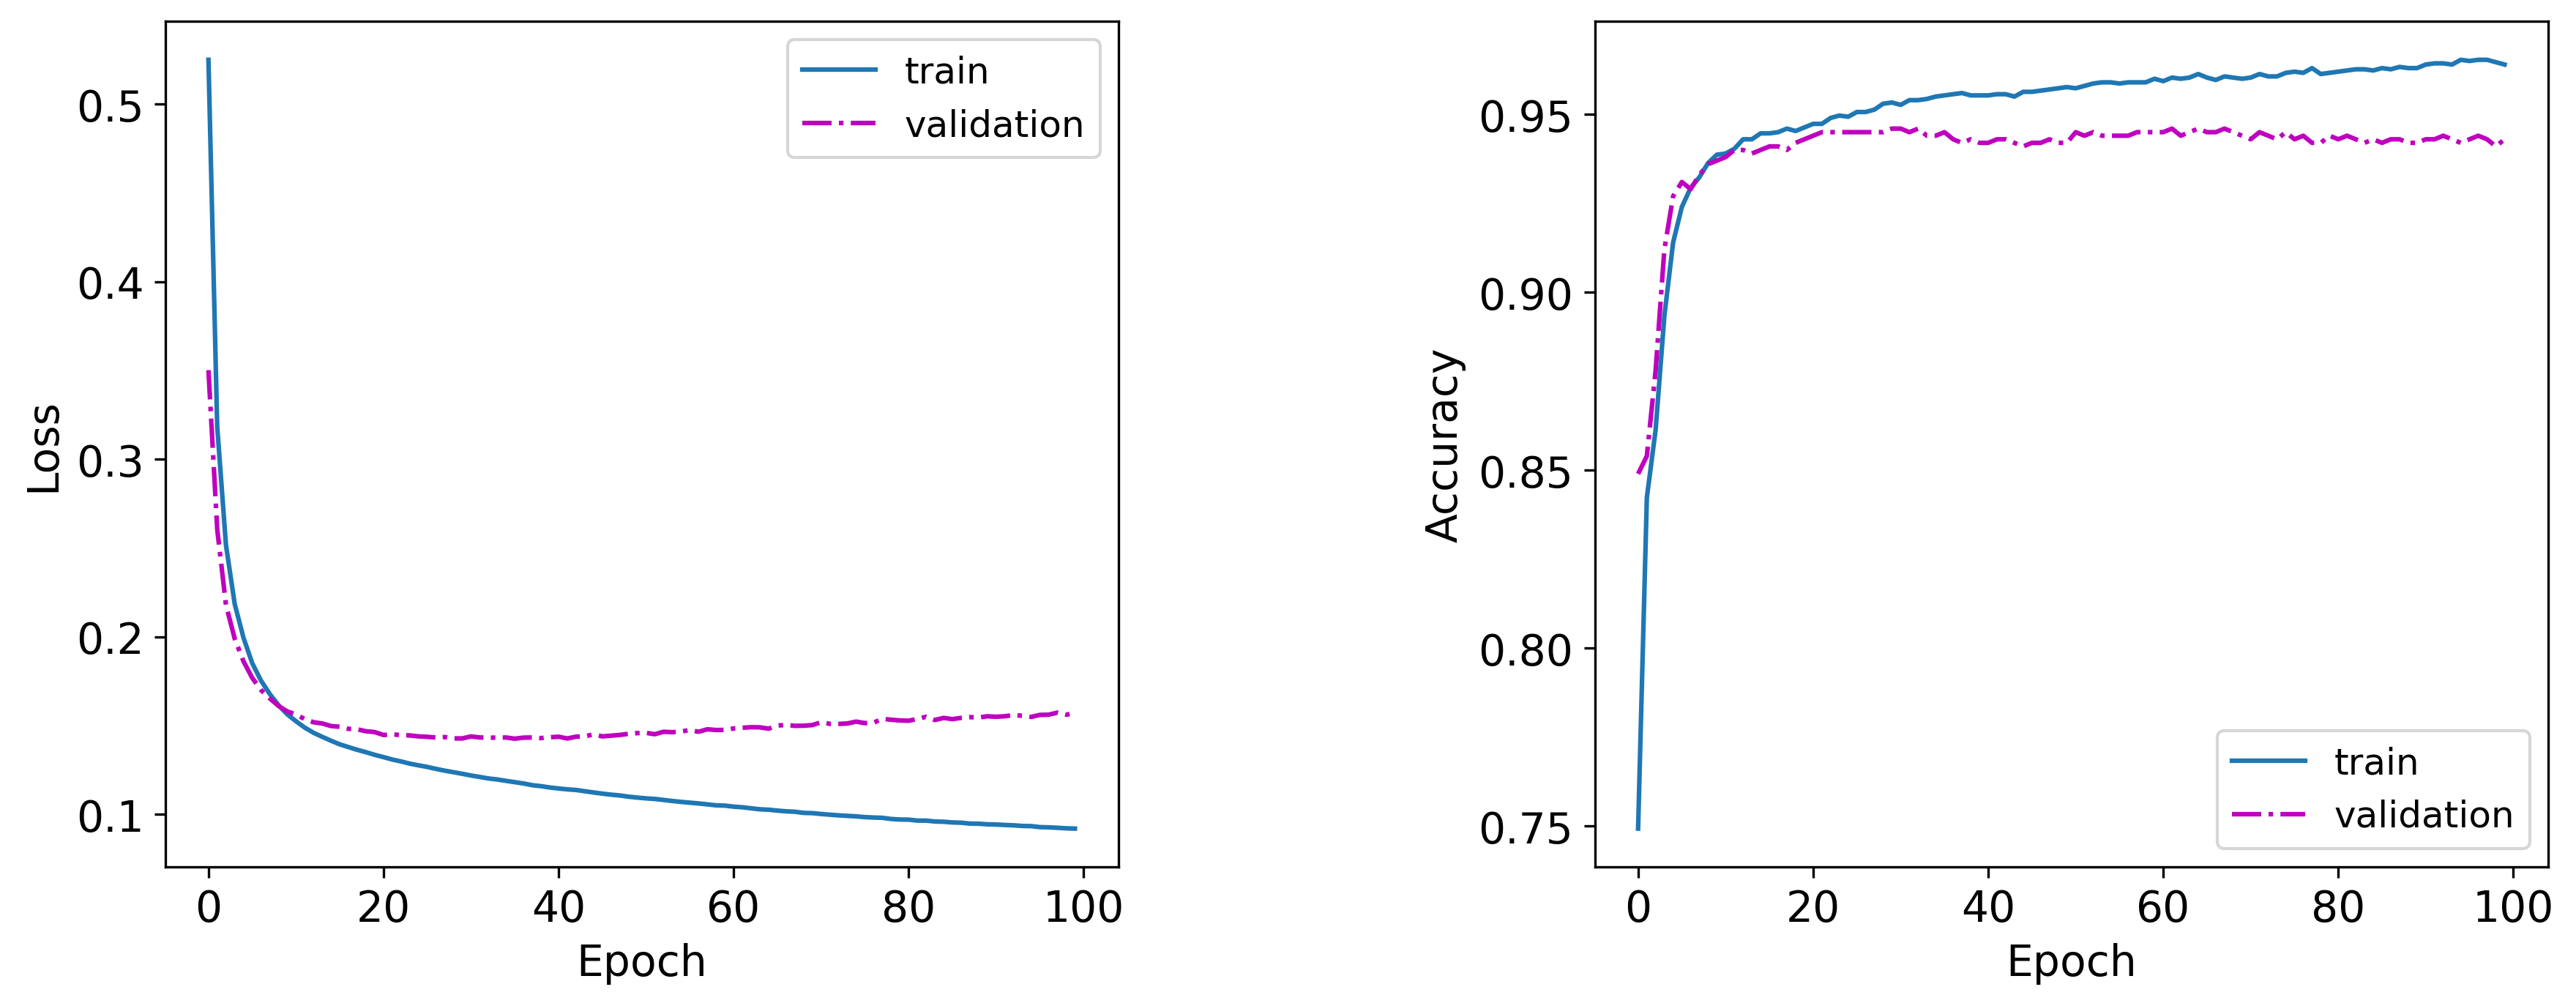

In [28]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train')
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)
#plt.show()

#plt.savefig('ScaledNN.png', dpi= 300)

### Questions:
- Do you observe high bias? What about high variance?
- How does the validation accuracy compare to our SVM model with these features (reminder, that model had a test accuracy of 94.2% +/- 0.6%)?

>There is some high variance but not high bias. 

>The test accuracy is similar to the SVM model's accuracy. 

#### As you can see, this network is much better behaved, and it achieves a final accuracy similar to the one found by SVMs (this is common for tabular data like ours). 

#### We do so see some signs of high variance in the accuracy/validation curve; some regularization technique, such as a Dropout layer, may help. Early stopping (not shown here) would also be worth trying.

In [29]:

model = Sequential()
# Tell subsequent layers what shape to expect
model.add(keras.Input(shape=(24,)))
# Add an input layer and specify its size (number of original features)

model.add(Dense(20, activation='relu', input_shape=(24,)))

model.add(Dropout(0.2)) #This is the dropout fraction

# Add one hidden layer and specify its size

model.add(Dense(20, activation='relu'))

model.add(Dropout(0.2)) #This is the dropout fraction

# Add an output layer 

model.add(Dense(1, activation='sigmoid'))

optimizer = keras.optimizers.AdamW(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics = ['accuracy']) 

/opt/anaconda3/envs/phy448_deeplearning/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
mynet = model.fit(Xst_train, y_train, validation_data= (Xst_val, y_val), epochs=100, batch_size=200)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5200 - loss: 0.7410 - val_accuracy: 0.6670 - val_loss: 0.6302
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7127 - loss: 0.5944 - val_accuracy: 0.8340 - val_loss: 0.5035
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8067 - loss: 0.4834 - val_accuracy: 0.8730 - val_loss: 0.4181
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8507 - loss: 0.4146 - val_accuracy: 0.8840 - val_loss: 0.3566
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8713 - loss: 0.3628 - val_accuracy: 0.8920 - val_loss: 0.3095
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8853 - loss: 0.3234 - val_accuracy: 0.9090 - val_loss: 0.2725
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8950 - loss: 0.2846 - val_accuracy: 0.9130 - val_loss: 0.2436
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9077 - loss: 0.2556 - val_accuracy: 0.

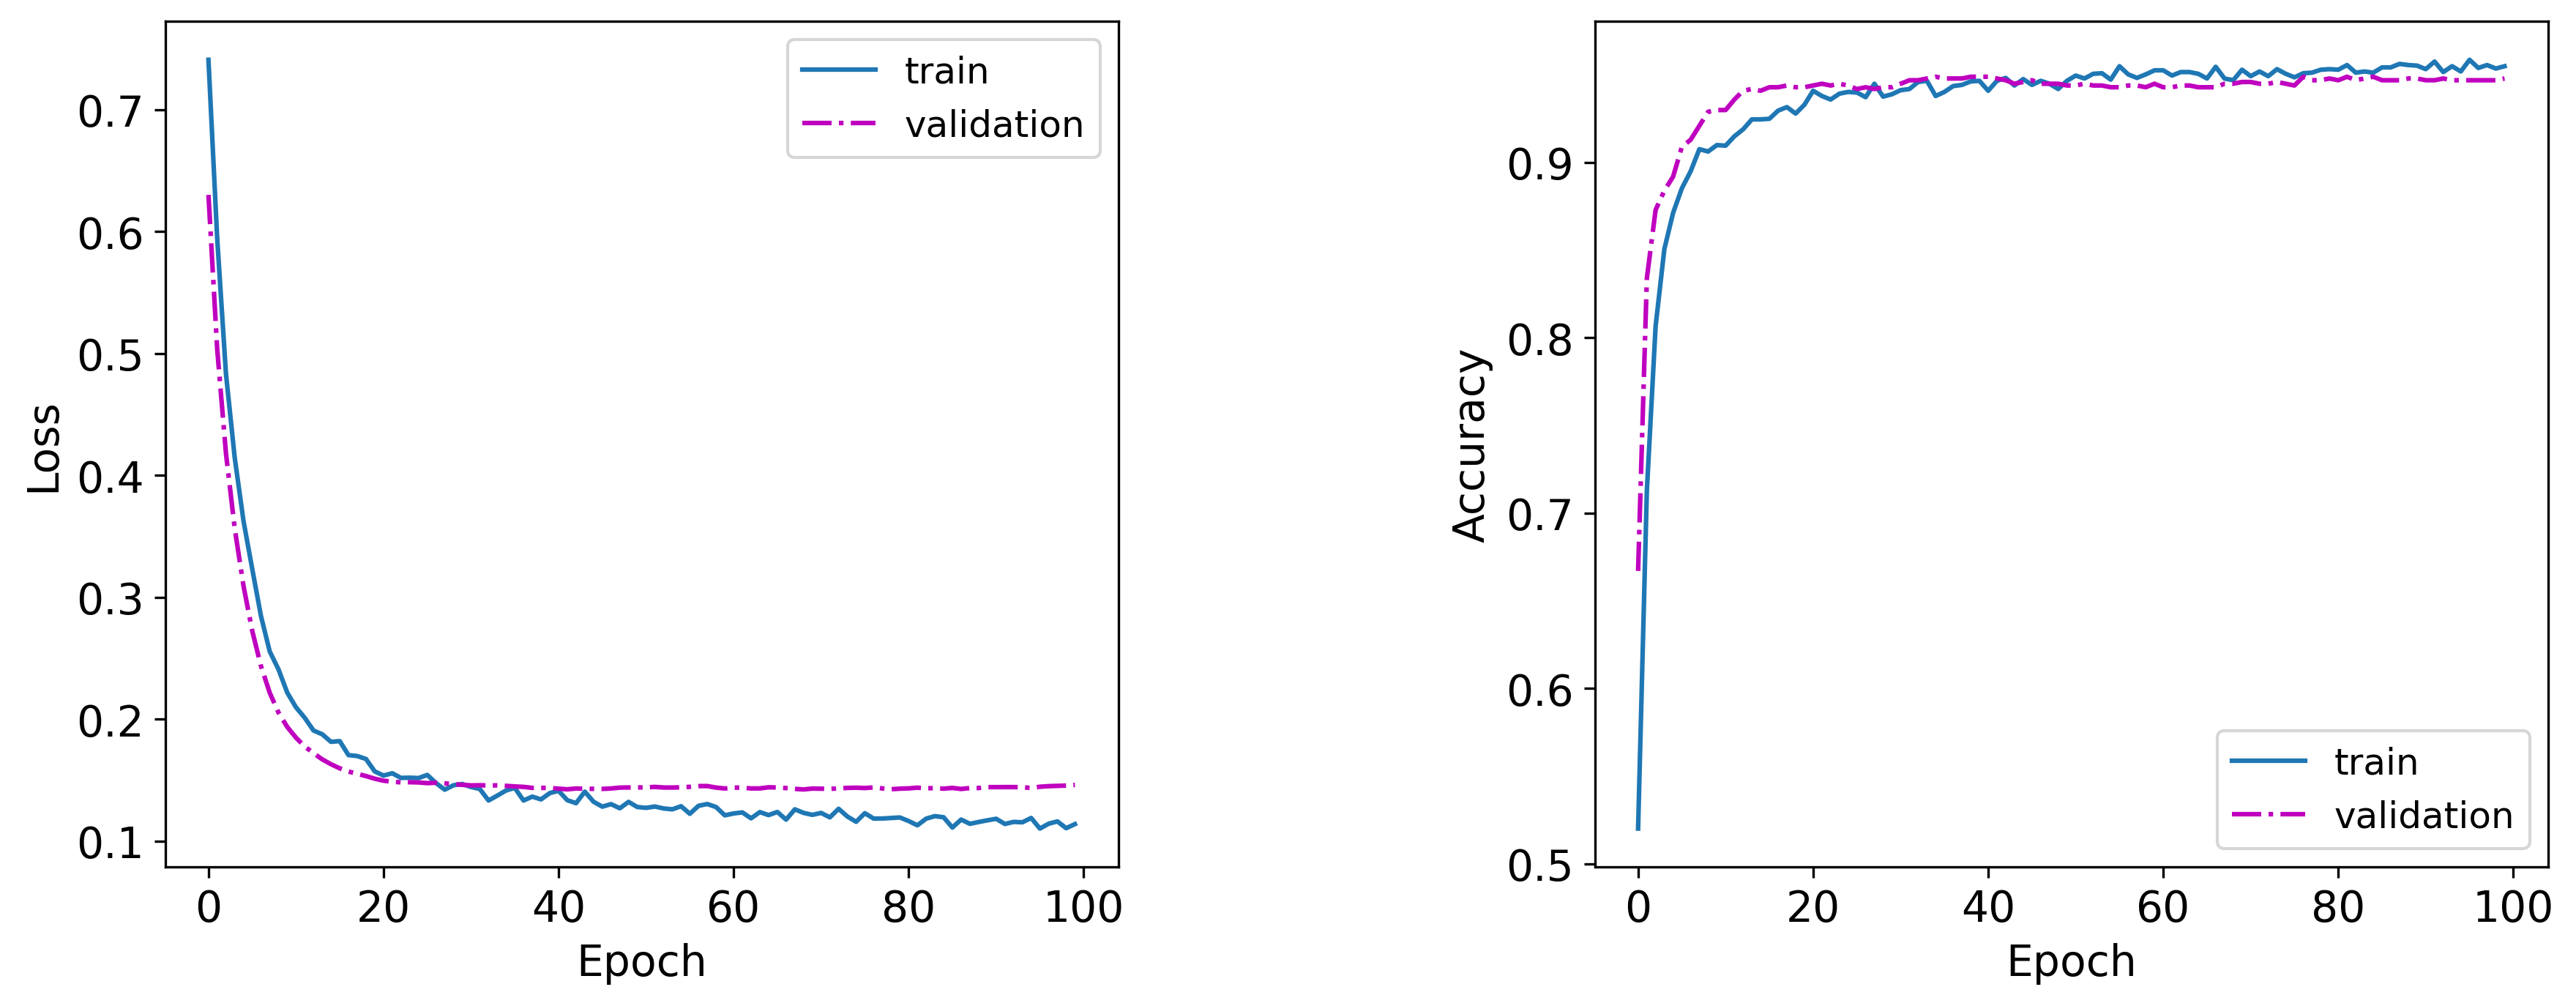

In [31]:
plt.figure(figsize=(14,5))

plt.subplot(121)

plt.plot(mynet.history['loss'], label = 'train')
plt.plot(mynet.history['val_loss'],'-.m', label = 'validation')
plt.ylabel('Loss', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(loc='upper right', fontsize = 12)

plt.subplot(122)

plt.plot(mynet.history['accuracy'], label = 'train')
plt.plot(mynet.history['val_accuracy'], '-.m', label = 'validation')
plt.ylabel('Accuracy', fontsize = 14)
plt.xlabel('Epoch', fontsize = 14)
plt.legend(fontsize = 12)
plt.subplots_adjust(wspace=0.5)

#plt.savefig('RegularizedNN.png', dpi= 300)
#plt.show()

### The final evaluation of the model is always done on the test set; the reason is that the validation fold is used for hyperparameter optimization (which we haven't done here), and test set is blind to it.


In [32]:
scores = model.evaluate(Xst_test, y_test, verbose=1)

print("Accuracy: %.2f%%" % (scores[1]*100))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9350 - loss: 0.1759
Accuracy: 93.50%


In [33]:
 #"scores" contains the test loss and the accuracy, which we are monitoring.

scores

[0.17587445676326752, 0.9350000023841858]

### Questions:
- How does the performance of this 2 layer fully-connected neural network compare to the performance of the SVMs you tested?
- Which one would you prefer to use: this fully-connected NN or the SVM? Give at least 2 arguments as for why your chosen method is the preferable one.

>It is comparable but slightly worse than the SVMs we tested. 93.5 vs 94 percent accuracy is similar. 

>I would perfer to use the SVM because it was simpler and had fewer hypyerparameters. It is also computaitonally simpler which is always good. 

### Acknowledgement Statement:

The authors acknowledge Dr. Gruszko's help with understanding the batch size. 

Once you're done with this notebook, move on to the photometric redshift neural network example.